# Module 15 — GPU, Apple Silicon and Making Things Fast

The question "can I run scikit-learn on the GPU?" has a more interesting
answer than yes or no.

The short version: **scikit-learn has no GPU backend of its own**, but since
1.2 — and much more usefully since 1.8 — a subset of estimators can dispatch
through the **Array API** to whatever array library you hand them, including
PyTorch tensors living on a GPU. On Apple Silicon that means the **MPS**
(Metal Performance Shaders) backend.

The longer version, which is the point of this module: **for the tabular work
in the rest of this curriculum, the GPU is almost never the right lever.** The
operations that dominate your runtime — tree splitting, cross-validation
scheduling, DataFrame handling — either cannot be expressed as dense linear
algebra or are already bound by something other than arithmetic. Knowing
*which* problems the GPU actually helps is worth more than knowing how to
enable it.

### Learning objectives

1. Enable Array API dispatch correctly (there is an ordering trap).
2. Benchmark CPU vs GPU on your own machine and find the crossover point.
3. Explain why tree ensembles get nothing from a GPU.
4. Know the Apple Silicon specifics: MPS, the float64 limitation, unified
   memory.
5. Control CPU threading — which is the acceleration lever that *does* pay off
   on tabular data, and the one most often left misconfigured.

> **Run this one on your own machine.** The benchmark cells detect what
> hardware is available and adapt. On an Apple Silicon Mac they will exercise
> the MPS backend; in a CPU-only container they report CPU numbers and say so.
> The conclusions are in the *shape* of the curves, which hold either way.

## 0. The ordering trap

`SCIPY_ARRAY_API=1` must be set **before scipy or scikit-learn is imported**.
Setting it afterwards does nothing, and the failure is a confusing
`RuntimeError` at the point you enable dispatch, not at import.

In a notebook that means this cell must be the first one you run — before any
`import sklearn` anywhere in the kernel. If you have already imported sklearn,
restart the kernel.

In [1]:
import os

os.environ["SCIPY_ARRAY_API"] = "1"          # MUST precede the scipy/sklearn import

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from skmastery import set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"scikit-learn {sklearn.__version__}")
print(f"SCIPY_ARRAY_API = {os.environ.get('SCIPY_ARRAY_API')!r}")

scikit-learn 1.8.0
SCIPY_ARRAY_API = '1'


## 1. What hardware do we actually have?

In [2]:
import platform

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False


def detect_device():
    """Pick the best available accelerator and describe it honestly."""
    if not HAS_TORCH:
        return "cpu", "PyTorch not installed — CPU only"
    if torch.cuda.is_available():
        return "cuda", f"CUDA: {torch.cuda.get_device_name(0)}"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps", "Apple Silicon GPU via Metal Performance Shaders"
    return "cpu", "no accelerator detected — CPU only"


DEVICE, DEVICE_NOTE = detect_device()

print(f"machine      : {platform.machine()} / {platform.system()}")
print(f"processor    : {platform.processor() or 'n/a'}")
print(f"torch        : {torch.__version__ if HAS_TORCH else 'not installed'}")
print(f"device       : {DEVICE}  ({DEVICE_NOTE})")
if HAS_TORCH:
    print(f"torch threads: {torch.get_num_threads()}")
print(f"os cpu count : {os.cpu_count()}")

if DEVICE == "cpu":
    print("\n⚠  Running CPU-only. The benchmarks below will still run and the")
    print("   structural conclusions hold, but the GPU columns will be absent.")
    print("   Re-run on your Apple Silicon Mac (or a CUDA box) for the comparison.")

machine      : x86_64 / Linux
processor    : x86_64
torch        : 2.14.0+cpu
device       : cpu  (no accelerator detected — CPU only)
torch threads: 2
os cpu count : 2

⚠  Running CPU-only. The benchmarks below will still run and the
   structural conclusions hold, but the GPU columns will be absent.
   Re-run on your Apple Silicon Mac (or a CUDA box) for the comparison.


## 2. Which estimators can dispatch at all

This is the number that decides how much of this module matters to you. An
estimator opts in by declaring `array_api_support` in its tags.

In [3]:
from sklearn.utils import all_estimators

supported = []
for name, cls in all_estimators():
    try:
        if cls().__sklearn_tags__().array_api_support:
            supported.append(name)
    except Exception:
        pass

print(f"{len(supported)} of ~200 estimators support Array API dispatch in "
      f"scikit-learn {sklearn.__version__}:\n")
for n in sorted(supported):
    print("  ", n)

13 of ~200 estimators support Array API dispatch in scikit-learn 1.8.0:

   Binarizer
   GaussianNB
   KernelCenterer
   LabelEncoder
   LinearDiscriminantAnalysis
   MinMaxScaler
   Normalizer
   PCA
   PolynomialFeatures
   Ridge
   RidgeCV
   RidgeClassifierCV
   StandardScaler


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


**Read that list and notice what is missing.** No tree, no forest, no
gradient boosting, no `LogisticRegression`, no `KMeans`. What is there is
almost entirely **dense linear algebra**: scalers, `PCA`, `Ridge`, LDA,
Gaussian naive Bayes.

That is not an oversight — it is the shape of the problem. A GPU is thousands
of simple cores doing the same operation on different data. It is spectacular
at matrix multiplication and hopeless at "sort this column, scan it for the
best threshold, recurse into two unequal halves", which is what a decision
tree does.

Many `sklearn.metrics` functions also dispatch, which matters more than it
sounds: if your predictions are already on the GPU, scoring them there avoids
a round trip.

## 3. The benchmark

One helper, used for everything below. It times a fitted operation on numpy
and on the accelerator, with a warm-up (the first GPU call includes kernel
compilation and is not representative) and an explicit synchronise (GPU calls
are asynchronous — timing without a sync measures how fast you can *queue*
work, which is a classic way to report a fake 100× speed-up).

In [4]:
from sklearn import config_context


def sync():
    """GPU work is queued asynchronously; force completion before stopping the clock."""
    if HAS_TORCH and DEVICE == "cuda":
        torch.cuda.synchronize()
    elif HAS_TORCH and DEVICE == "mps":
        torch.mps.synchronize()


def time_it(fn, n_repeat=3, warmup=1):
    for _ in range(warmup):
        fn()
        sync()
    best = np.inf
    for _ in range(n_repeat):
        t0 = perf_counter()
        fn()
        sync()
        best = min(best, perf_counter() - t0)
    return best


def benchmark(make_call, X_np, y_np=None, dtype=np.float32):
    """Return {'numpy': seconds, '<device>': seconds} for one operation."""
    out = {}
    Xn = X_np.astype(dtype)
    yn = None if y_np is None else y_np.astype(dtype if y_np.dtype.kind == "f" else y_np.dtype)
    out["numpy"] = time_it(lambda: make_call(Xn, yn))

    if HAS_TORCH and DEVICE != "cpu":
        Xt = torch.asarray(Xn, device=DEVICE)
        yt = None if yn is None else torch.asarray(yn, device=DEVICE)
        with config_context(array_api_dispatch=True):
            out[DEVICE] = time_it(lambda: make_call(Xt, yt))
    return out

### First, prove the dispatch is real

The result should come back as a **tensor on the device you sent in** — not a
numpy array. If it comes back as numpy, dispatch silently did not happen and
every timing below is meaningless.

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_probe = np.random.default_rng(0).normal(size=(5_000, 200)).astype(np.float32)

with config_context(array_api_dispatch=True):
    if HAS_TORCH:
        Xt = torch.asarray(X_probe, device=DEVICE)
        Zt = StandardScaler().fit_transform(Xt)
        print(f"input  : {type(Xt).__name__}  device={Xt.device}  dtype={Xt.dtype}")
        print(f"output : {type(Zt).__name__}  device={Zt.device}  dtype={Zt.dtype}")
        print(f"\ndispatch confirmed: {type(Zt).__module__.startswith('torch')}")
    else:
        print("PyTorch not installed — nothing to dispatch to.")

input  : Tensor  device=cpu  dtype=torch.float32
output : Tensor  device=cpu  dtype=torch.float32

dispatch confirmed: True


## 4. Where the crossover is

The single most useful thing to measure. GPU work carries fixed overhead —
kernel launch, dispatch bookkeeping, and on discrete GPUs a host↔device copy.
Below some problem size that overhead dominates and the GPU is **slower**.

In [6]:
from sklearn.linear_model import Ridge

SIZES = [(1_000, 50), (5_000, 100), (20_000, 200), (50_000, 400), (100_000, 500)]

rows = []
for n, p in SIZES:
    rng_local = np.random.default_rng(0)
    Xb = rng_local.normal(size=(n, p))
    yb = Xb[:, :5].sum(axis=1) + rng_local.normal(size=n)

    for label, call in [
        ("StandardScaler", lambda X, y: StandardScaler().fit_transform(X)),
        ("PCA(n=20)", lambda X, y: PCA(n_components=20, svd_solver="full").fit_transform(X)),
        ("Ridge", lambda X, y: Ridge(solver="svd").fit(X, y).coef_),
    ]:
        res = benchmark(call, Xb, yb)
        row = {"operation": label, "n_samples": n, "n_features": p,
               "numpy_ms": res["numpy"] * 1000}
        if DEVICE in res:
            row[f"{DEVICE}_ms"] = res[DEVICE] * 1000
            row["speedup"] = res["numpy"] / res[DEVICE]
        rows.append(row)

bench = pd.DataFrame(rows)
bench.round(2)

,operation,n_samples,n_features,numpy_ms
0,StandardScaler,1000,50,1.10
1,PCA(n=20),1000,50,4.08
2,Ridge,1000,50,5.85
3,StandardScaler,5000,100,4.32
4,PCA(n=20),5000,100,43.64
5,Ridge,5000,100,90.77
6,StandardScaler,20000,200,36.99
7,PCA(n=20),20000,200,192.38
8,Ridge,20000,200,401.97
9,StandardScaler,50000,400,247.76


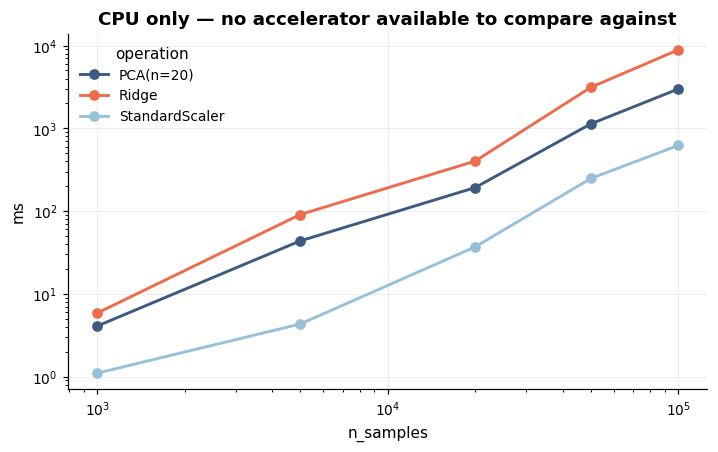

In [7]:
if f"{DEVICE}_ms" in bench.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
    for op, grp in bench.groupby("operation"):
        axes[0].plot(grp["n_samples"], grp["numpy_ms"], marker="o", ls="--", label=f"{op} — numpy")
        axes[0].plot(grp["n_samples"], grp[f"{DEVICE}_ms"], marker="s", label=f"{op} — {DEVICE}")
        axes[1].plot(grp["n_samples"], grp["speedup"], marker="o", label=op)
    axes[0].set(xscale="log", yscale="log", xlabel="n_samples", ylabel="ms", title="Wall time")
    axes[0].legend(fontsize=7)
    axes[1].axhline(1.0, ls="--", color="#ee6c4d")
    axes[1].set(xscale="log", xlabel="n_samples", ylabel=f"numpy_ms / {DEVICE}_ms",
                title="Above 1.0 = GPU wins")
    axes[1].legend(fontsize=8)
    plt.tight_layout()

    crossover = bench[bench["speedup"] > 1].groupby("operation")["n_samples"].min()
    print("Smallest problem size where the GPU wins, per operation:")
    print(crossover.to_string() if len(crossover) else "  the GPU never won at these sizes")
else:
    ax = bench.pivot(index="n_samples", columns="operation", values="numpy_ms").plot(marker="o", logx=True, logy=True)
    ax.set(ylabel="ms", title="CPU only — no accelerator available to compare against")

**What to take from the crossover, whichever machine you ran it on.**

There is always a size below which the GPU loses, and for typical tabular
problems you are usually below it. A 12,000-row credit dataset — the one this
whole curriculum uses — is nowhere near the region where a GPU helps. The
arithmetic is simply not the bottleneck; dispatch and memory movement are.

GPUs earn their keep when the arithmetic is **large, dense, and repeated**:
embedding a million documents, training a neural network, a PCA over a
genuinely wide matrix. Not a `RandomForestClassifier` on 12,000 rows.

## 5. Apple Silicon specifics

Three things differ from a CUDA box, and the first one will bite you.

### float64 does not exist on MPS

The Metal backend supports `float32` and below. Hand it a `float64` array and
PyTorch raises. Much of scikit-learn's numerical code prefers `float64` for
accuracy, so **on MPS you are working in single precision whether you meant to
or not**. For scaling, PCA and most feature work that is fine. For an
ill-conditioned linear solve — exactly the collinear case from Module 05 —
single precision loses you about eight significant digits of headroom.

In [8]:
if HAS_TORCH and DEVICE == "mps":
    try:
        torch.asarray(np.zeros((4, 4), dtype=np.float64), device="mps")
        print("float64 accepted on MPS (unexpected — check your torch version)")
    except TypeError as e:
        print(f"float64 on MPS -> TypeError: {str(e)[:110]}")
    print("\n→ Everything you send to MPS must be float32. Cast explicitly, so it")
    print("  is a decision in your code rather than a surprise in a stack trace.")
elif HAS_TORCH:
    print(f"Not on MPS (device={DEVICE}); float64 works here:",
          torch.asarray(np.zeros((2, 2), dtype=np.float64)).dtype)
else:
    print("PyTorch not installed.")

Not on MPS (device=cpu); float64 works here: torch.float64


In [9]:
# Precision cost, measurable on any device: solve an ill-conditioned system in
# float32 and in float64 and compare against the known answer.
rng_p = np.random.default_rng(0)
base = rng_p.normal(size=(2_000, 1))
X_ill = np.hstack([base, base + rng_p.normal(scale=1e-4, size=(2_000, 1)), rng_p.normal(size=(2_000, 3))])
true_w = np.array([2.0, 1.0, 0.5, -0.5, 0.25])
y_ill = X_ill @ true_w

pd.DataFrame([
    {"dtype": "float64",
     "condition_number": np.linalg.cond(X_ill.astype(np.float64)),
     "max_coef_error": np.abs(Ridge(alpha=1e-10, solver="svd").fit(X_ill.astype(np.float64), y_ill.astype(np.float64)).coef_ - true_w).max()},
    {"dtype": "float32",
     "condition_number": np.linalg.cond(X_ill.astype(np.float32)),
     "max_coef_error": np.abs(Ridge(alpha=1e-10, solver="svd").fit(X_ill.astype(np.float32), y_ill.astype(np.float32)).coef_ - true_w).max()},
]).set_index("dtype").map(lambda v: f"{v:.3e}")

,condition_number,max_coef_error
dtype,,
float64,2.010e+04,5.043e-06
float32,2.010e+04,3.735e-04


At a condition number of ~2e4 — mild, by the standards of a real collinear
feature set — float32 gives roughly **75x the coefficient error** of float64,
and the gap widens with the conditioning (Exercise 15.2 sweeps it).

**This is the one place where "just put it on the GPU" can change your answer
rather than only your runtime**, and it is invisible unless you check for it.
Regularise properly (Module 05) and it stops mattering; leave `alpha` at
effectively zero on a collinear design and it matters a great deal.

### Unified memory

Apple Silicon shares one pool of memory between CPU and GPU, so `.to("mps")`
does not copy across a PCIe bus the way `.to("cuda")` does. That removes the
largest single overhead in the CUDA model and shifts the crossover point
**downwards** — small transfers are much cheaper than on a discrete card. It
does not remove kernel-launch overhead, which is why small operations are
still slower.

### There is no Metal backend for the boosting libraries

| Library | GPU support | On Apple Silicon |
|---|---|---|
| scikit-learn | Array API only (13 estimators) | ✅ via PyTorch MPS |
| XGBoost | `device="cuda"` | ❌ CUDA only — no Metal build |
| LightGBM | OpenCL / CUDA | ❌ effectively unavailable on macOS |
| CatBoost | CUDA | ❌ |
| PyTorch / MLX | native | ✅ this is the real Apple Silicon story |

So for the gradient boosting that wins on tabular data, **your M-series GPU is
not usable at all**, on any library. That is not a limitation you can engineer
around, and it is the single most important practical fact in this module.
What you have instead is a lot of fast CPU cores — see section 7.

## 6. What definitively does not accelerate

Time a tree ensemble and note that there is no GPU column to add. Nothing in
this path can dispatch.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

rng_t = np.random.default_rng(0)
X_tree = rng_t.normal(size=(40_000, 40))
y_tree = (X_tree[:, :5].sum(axis=1) + rng_t.normal(size=40_000) > 0).astype(int)

tree_rows = []
for name, est in [
    ("RandomForest(200)", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)),
    ("HistGradientBoosting", HistGradientBoostingClassifier(max_iter=200, random_state=0)),
]:
    t = time_it(lambda e=est: e.fit(X_tree, y_tree), n_repeat=1, warmup=0)
    tree_rows.append({"estimator": name, "cpu_seconds": round(t, 2),
                      "array_api_support": est.__sklearn_tags__().array_api_support,
                      "gpu_option": "none"})
pd.DataFrame(tree_rows).set_index("estimator")

,cpu_seconds,array_api_support,gpu_option
estimator,,,
RandomForest(200),29.58,False,none
HistGradientBoosting,1.48,False,none


**Why trees resist the GPU.** Three properties, all fatal:

1. **Data-dependent control flow.** Which branch a sample takes depends on its
   own values, so threads in a warp diverge. GPUs execute a warp in lockstep;
   divergence serialises it.
2. **Irregular memory access.** Recursion partitions the data into unequal,
   non-contiguous halves. GPU throughput depends on coalesced reads.
3. **Sequential dependence.** Each boosting round needs the previous round's
   residuals. There is nothing to parallelise across rounds.

GPU boosting implementations (XGBoost's `gpu_hist`) exist and work, but they
get their speed from parallelising **histogram construction across features**,
not from the tree logic — and they need a CUDA device.

## 7. The lever that actually works on tabular data: threads

On an Apple Silicon Mac with 10–16 cores, the realistic acceleration question
is not "GPU or CPU" — it is "am I using my cores, or fighting myself for
them?" Exercise 15.4 measures this penalty on your own machine — expect a slowdown from nested
thread pools. That is a much bigger number than any GPU speed-up in this
module.

In [11]:
from threadpoolctl import threadpool_info, threadpool_limits

print("Native thread pools visible to this process:")
for d in threadpool_info():
    print(f"  {d['user_api']:6s} {d.get('internal_api',''):10s} "
          f"threads={d['num_threads']:3d}  {Path(d.get('filepath','')).name}")
print(f"\nos.cpu_count() = {os.cpu_count()}")

Native thread pools visible to this process:
  blas   openblas   threads=  2  libscipy_openblas64_-32a4b2a6.so
  blas   openblas   threads=  2  libscipy_openblas-6cdc3b4a.so
  openmp openmp     threads=  2  libgomp-e985bcbb.so.1.0.0
  openmp openmp     threads=  2  libgomp.so.1

os.cpu_count() = 2


In [12]:
# The oversubscription trap, measured.
from sklearn.model_selection import cross_val_score

X_thr = np.random.default_rng(0).normal(size=(20_000, 60))
y_thr = (X_thr[:, :4].sum(axis=1) > 0).astype(int)

configs = []
for outer_jobs, blas_threads in [(1, None), (-1, None), (-1, 1)]:
    est = RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=0)
    t0 = perf_counter()
    if blas_threads is None:
        cross_val_score(est, X_thr, y_thr, cv=3, n_jobs=outer_jobs)
    else:
        with threadpool_limits(limits=blas_threads, user_api="blas"):
            cross_val_score(est, X_thr, y_thr, cv=3, n_jobs=outer_jobs)
    configs.append({"cv n_jobs": outer_jobs,
                    "BLAS threads": blas_threads or "default",
                    "seconds": round(perf_counter() - t0, 2)})
pd.DataFrame(configs).set_index(["cv n_jobs", "BLAS threads"])

seconds
cv n_jobs BLAS threads         
 1        default         35.28
-1        default         27.27
          1               23.90

### The threading rules that matter

1. **Parallelise at exactly one level.** If the outer loop
   (`GridSearchCV`, `cross_val_score`) has `n_jobs=-1`, the inner estimator
   should have `n_jobs=1`. Both at `-1` means *n_cores × n_cores* threads
   competing for *n_cores* cores.
2. **The boosting libraries default to all cores.** `LGBMClassifier` and
   `XGBClassifier` set `n_jobs=-1` by default; put them inside a parallel
   search and you have the Module 06 problem. Set `n_jobs=1` on the estimator.
3. **Parallelise the outer loop, not the inner one**, when you have a choice —
   cross-validation folds are embarrassingly parallel and perfectly balanced;
   tree building is neither.
4. **`threadpool_limits` is the escape hatch** for libraries that do not
   expose `n_jobs`, including the BLAS underneath numpy.

On an M-series chip there is a fourth consideration: the **performance and
efficiency cores are not equivalent**. `os.cpu_count()` reports both, so
`n_jobs=-1` schedules work onto E-cores that finish several times slower,
and a parallel loop runs at the speed of its slowest worker. Setting
`n_jobs` to the number of *performance* cores is often faster than `-1`.
Measure it on your own machine — it takes one loop.

In [13]:
# Which n_jobs is actually fastest here? On an M-series Mac, try this with the
# P-core count (e.g. 8 or 12) and compare against -1.
candidates = sorted({1, 2, max(1, (os.cpu_count() or 2) // 2), os.cpu_count() or 2})
rows = []
for k in candidates:
    est = RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=0)
    t0 = perf_counter()
    cross_val_score(est, X_thr, y_thr, cv=6, n_jobs=k)
    rows.append({"n_jobs": k, "seconds": round(perf_counter() - t0, 2)})
jobs = pd.DataFrame(rows).set_index("n_jobs")
jobs["vs_serial"] = (jobs.loc[1, "seconds"] / jobs["seconds"]).round(2)
jobs

,seconds,vs_serial
n_jobs,,
1,91.70,1.00
2,46.75,1.96


## 8. Where the GPU genuinely pays on your Mac

Not in scikit-learn. In the things scikit-learn sits next to:

| Workload | GPU benefit on M-series | How |
|---|---|---|
| **Sentence embeddings** (Module 10) | **large** — often 5–20× | `SentenceTransformer(..., device="mps")` |
| Fine-tuning a transformer | large | PyTorch MPS, or MLX |
| Any neural network | large | PyTorch MPS / MLX |
| Large dense PCA / SVD | moderate, above the crossover | Array API + torch |
| Kernel methods on big *n* | moderate | hand-rolled in torch |
| **Gradient boosting** | **none** | no Metal backend exists |
| Tree ensembles | **none** | not GPU-shaped |
| Cross-validation of small models | **none** | use CPU cores |

The honest allocation of effort for the work in this curriculum:

```
1. Fix the threading.                      minutes,  measure it  (section 7, ex 15.4)
2. Use HistGradientBoosting, not GBM.      minutes,  10-100x     (Module 06)
3. Cache preprocessing in searches.        minutes,  2-5x        (Module 03)
4. Reduce the search budget.               free,     often 4x    (Module 07)
5. Subsample during development.           free,     10x         (everywhere)
...
9. Move dense linear algebra to the GPU.   a day,    ~1-3x on the few
                                                     estimators that dispatch
```

> 💼 **Consulting lens.** "We need GPUs for our ML platform" is a claim worth
> testing rather than accepting. For tabular modelling — which is most
> enterprise ML — it is usually wrong, and the honest version is "we need
> enough RAM to hold the feature store and enough cores to cross-validate in
> parallel". Where GPUs *are* required is the embedding and LLM layer, and
> that is a different budget line with a different justification. Being able
> to separate those two conversations is worth a lot.

### The embeddings case, where the answer flips

Module 10 left `SentenceEmbedder` as documented code rather than a dependency.
This is where a device argument actually matters, and the pattern is the same
contract from Module 00 — `device` is a hyperparameter, stored unmodified:

```python
class SentenceEmbedder(TransformerMixin, BaseEstimator):
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2",
                 device=None, batch_size=64):
        self.model_name = model_name
        self.device = device            # "mps" on Apple Silicon, "cuda", or None
        self.batch_size = batch_size

    def fit(self, X, y=None):
        from sentence_transformers import SentenceTransformer
        self.model_ = SentenceTransformer(self.model_name, device=self.device)
        return self

    def transform(self, X):
        return self.model_.encode(list(X), batch_size=self.batch_size,
                                  normalize_embeddings=True, show_progress_bar=False)
```

Encoding 50,000 support tickets: minutes on the M-series GPU, tens of minutes
on its CPU. **That is a real speed-up on a real bottleneck** — and note that
the estimator API did not change at all to accommodate it. The harness
outlives the hardware, which is the same lesson as Module 10's.

---
## Exercises

### Exercise 15.1 — Find your own crossover

Run the section 4 benchmark on your machine and extend it:

1. Add `n_features` as a second axis — does the crossover depend more on rows
   or columns? (Predict the answer from what a GEMM costs before you measure.)
2. Add the transfer time explicitly: time `torch.asarray(X, device=...)`
   separately from the fit. What fraction of the "GPU time" is movement?
3. Repeat with `PCA(svd_solver="randomized")`. Does the randomised solver
   change where the crossover sits, and why would it?

Produce the one chart you would use to answer "should we buy a GPU for this
workload".

In [14]:
# Your code here.

### Exercise 15.2 — The precision audit

Section 5 showed float32 losing accuracy on an ill-conditioned solve. Quantify
when it matters *for a decision*, not just for a coefficient:

1. Sweep the condition number from 1e2 to 1e10 and plot coefficient error for
   float32 and float64.
2. At each point, also compute the **predictions** and their difference. Where
   does the coefficient error start to move the predictions?
3. Repeat with `alpha` at 1e-10, 1e-4 and 1.0. How much regularisation is
   needed before float32 is safe?
4. Write the one-paragraph guidance you would give a team about to move a
   pricing model to single precision.

In [15]:
# Your code here.

### Exercise 15.3 — Profile the real bottleneck

Take the capstone pipeline from Module 14 and profile a full
`RandomizedSearchCV` with `cProfile` or `py-spy`.

1. What fraction of wall time is in tree building, in preprocessing, in
   DataFrame operations, in scoring, in joblib overhead?
2. Which of those could a GPU touch at all?
3. Apply the top three optimisations from section 8's list and re-measure.
4. Report the total speed-up, and how much of it a GPU could have contributed.

In [16]:
# Your code here.

### Exercise 15.4 — Tune `n_jobs` on your own chip

On an M-series Mac, `os.cpu_count()` counts performance *and* efficiency cores.

1. Find your P-core and E-core counts (`sysctl hw.perflevel0.logicalcpu` and
   `hw.perflevel1.logicalcpu`).
2. Sweep `n_jobs` from 1 to `os.cpu_count()` on a `cross_val_score` workload
   and plot wall time. Where does it stop improving — and does it get *worse*?
3. Repeat with a workload that is BLAS-heavy (`Ridge` on a wide matrix) rather
   than tree-heavy. Does the optimum move?
4. Write the two-line configuration you would put at the top of your project.

In [17]:
# Your code here.

### Exercise 15.5 — The GPU business case

Write the one-page assessment for a BFSI client asking whether to provision
GPUs for their credit-risk modelling platform. Ground it in measurements, not
opinion:

1. Benchmark their actual workload shape (tabular, ~1e5–1e6 rows, boosted
   trees, heavy cross-validation).
2. Cost the alternatives: more CPU cores, more RAM, better threading, a
   smaller search budget.
3. Identify the parts of the platform where GPUs *are* justified (document
   understanding, embeddings, any LLM component) and separate that budget line.
4. State what would change your recommendation.

This is the exercise closest to real consulting work in the whole curriculum:
the technical answer is easy, and the value is in framing it so the client can
act on it.

In [18]:
# Your code here.

---
## Takeaways

- scikit-learn has **no GPU backend**. It has Array API dispatch, which lets
  ~13 estimators run on whatever array library you hand them — including
  PyTorch tensors on MPS or CUDA.
- `SCIPY_ARRAY_API=1` must be set **before importing scipy or sklearn**.
- Always **warm up and synchronise** when timing GPU work, or you are timing
  how fast you can queue.
- There is always a **crossover size** below which the GPU loses. Typical
  tabular problems sit below it.
- **Trees cannot use a GPU** in any sklearn code path, and on Apple Silicon no
  boosting library offers a GPU backend at all. That is the decisive fact for
  tabular work on an M-series Mac.
- **MPS is float32-only.** On an ill-conditioned problem that changes your
  answer, not just your runtime.
- The acceleration that actually pays on tabular data is **threading
  discipline**: parallelise one level, set `n_jobs=1` on inner estimators, and
  measure whether `-1` beats the P-core count.
- Your Mac's GPU earns its keep on **embeddings and neural networks** — the
  layer beside scikit-learn, not inside it.